# *Expectation–Maximization (EM) Algorithm*

## **Overview**
Expectation-Maximization (EM) algorithm is a iterative method used in unsupervised machine learning to find unknown values in statistical models. It helps to find the best values for unknown parameters especially when some data is missing or hidden. It works in two steps:

- **E-step (Expectation Step):** Estimates missing or hidden values using current parameter estimates.
- **M-step (Maximization Step):** Updates model parameters to maximize the likelihood based on the estimated values from the E-step.

## **Key Concepts**
- **Latent (hidden) variables (Z)**: Unobserved variables that influence data.
- **Observed data (X)**: The actual data we have.
- **Parameters (θ)**: Model parameters to be estimated.
- **Maximum Likelihood**: EM finds θ that maximizes the likelihood of X by iterating between estimation and maximization

## **Working of Algorithm**
### **1. Initialization:** The algorithm starts with initial parameter values and assumes the observed data comes from a specific model.
### **2. E-Step (Expectation Step):**
- Find the missing or hidden data based on the current parameters.
- Calculate the posterior probability of each latent variable based on the observed data.
- Compute the log-likelihood of the observed data using the current parameter estimates.
<!-- ### E-Step (Expectation) -->
Compute the **Q-function**:
$$
Q(\theta \mid \theta^{(t)}) = E_{Z \mid X, \theta^{(t)}}[\,\log p(X, Z \mid \theta)\,]
$$
This step calculates the expected complete-data log-likelihood, using current parameter estimates

### **3. M-Step (Maximization Step):**
- Update the model parameters by maximize the log-likelihood.
- The better the model the higher this value.
<!-- ### M-Step (Maximization) -->
Update the parameters:
$$
\theta^{(t+1)} = \arg\max_\theta Q(\theta \mid \theta^{(t)})
$$
This maximizes the Q-function to get improved parameter estimates

### **4. Convergence:**

- Check if the model parameters are stable and converging.
- If the changes in log-likelihood or parameters are below a set threshold, stop. If not repeat the E-step and M-step until convergence is reached
<br> <br>
![EM Algorithm Flowchart](https://media.geeksforgeeks.org/wp-content/uploads/20190512204358/EM21.jpg)

## **Theoretical Insight**
EM is proven to converge to a **local maximum** of the log-likelihood. The update improves the expected Q-function, which in turn increases the real log-likelihood through Jensen’s or Gibbs’ inequality.

## **Variants & Considerations**
- EM may converge **slowly** and often settles on local (not global) maxima.
- Variants such as **PX-EM**, **ECM**, **GEM**, and **accelerated EM** exist to improve convergence speed and robustness.

## **Application Example: Gaussian Mixture Models (GMM)**
In GMMs, EM is abundant:
- **E-Step**: Compute posterior probabilities for cluster memberships.
- **M-Step**: Update **means**, **covariances**, and **mixing coefficients**.

---

### Source: [GeeksforGeeks EM Algorithm Article](https://www.geeksforgeeks.org/machine-learning/ml-expectation-maximization-algorithm/)
---


# Import the necessary libraries

In [19]:
import numpy as np
import seaborn as sns
from scipy.stats import norm
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

# Generate a dataset with two Gaussian components
We generate two sets of data values from two different normal distributions:

- One centered around 2 (with more spread).
- Another around -1 (with less spread).


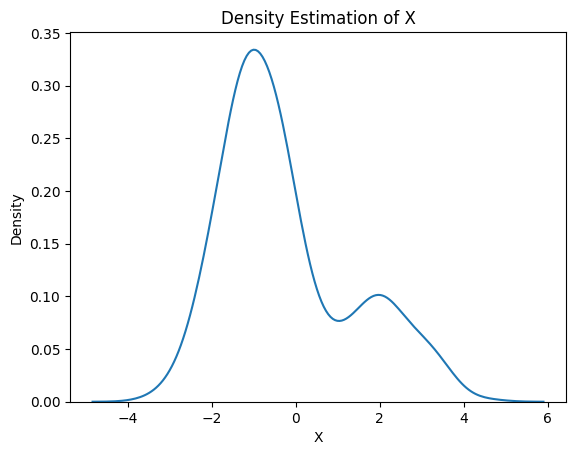

In [20]:
mu1, sigma1 = 2, 1
mu2, sigma2 = -1, 0.8
X1 = np.random.normal(mu1, sigma1, size=200)
X2 = np.random.normal(mu2, sigma2, size=600)
X = np.concatenate([X1, X2])

sns.kdeplot(X)
plt.xlabel('X')
plt.ylabel('Density')
plt.title('Density Estimation of X')
plt.show()

# Initialize parameters
We make initial guesses for each group’s:

- **Mean** (average),
- **Standard** deviation (spread),
- **Proportion** (how much each group contributes to the total data).

In [22]:
mu1_hat, sigma1_hat = np.mean(X1), np.std(X1)
mu2_hat, sigma2_hat = np.mean(X2), np.std(X2)
pi1_hat, pi2_hat = len(X1) / len(X), len(X2) / len(X)

# Perform EM algorithm
We run a loop for 20 rounds called epochs. In each round:

- The E-step calculates the responsibilities (gamma values) by evaluating the Gaussian probability densities for each component and weighting them by the corresponding proportions.
- The M-step updates the parameters by computing the weighted mean and standard deviation for each component
We also calculate the log-likelihood in each round to check if the model is getting better. This is a measure of how well the model explains the data.

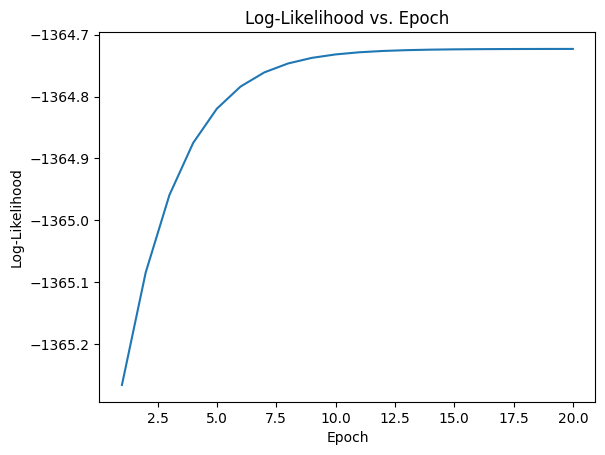

In [23]:
num_epochs = 20
log_likelihoods = []

for epoch in range(num_epochs):
    # E-step: Compute responsibilities
    gamma1 = pi1_hat * norm.pdf(X, mu1_hat, sigma1_hat)
    gamma2 = pi2_hat * norm.pdf(X, mu2_hat, sigma2_hat)
    total = gamma1 + gamma2
    gamma1 /= total
    gamma2 /= total
    
    # M-step: Update parameters
    mu1_hat = np.sum(gamma1 * X) / np.sum(gamma1)
    mu2_hat = np.sum(gamma2 * X) / np.sum(gamma2)
    sigma1_hat = np.sqrt(np.sum(gamma1 * (X - mu1_hat)**2) / np.sum(gamma1))
    sigma2_hat = np.sqrt(np.sum(gamma2 * (X - mu2_hat)**2) / np.sum(gamma2))
    pi1_hat = np.mean(gamma1)
    pi2_hat = np.mean(gamma2)
    
    # Compute log-likelihood
    log_likelihood = np.sum(np.log(pi1_hat * norm.pdf(X, mu1_hat, sigma1_hat)
                                   + pi2_hat * norm.pdf(X, mu2_hat, sigma2_hat)))
    log_likelihoods.append(log_likelihood)


plt.plot(range(1, num_epochs+1), log_likelihoods)
plt.xlabel('Epoch')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood vs. Epoch')
plt.show()

# Visualize the Final Result

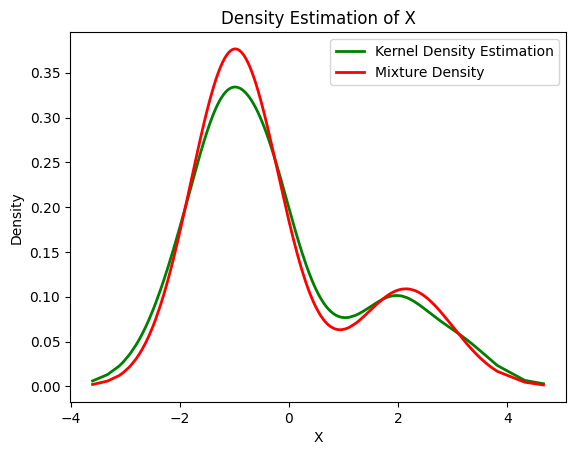

In [24]:
X_sorted = np.sort(X)
density_estimation = pi1_hat*norm.pdf(X_sorted,
                                        mu1_hat, 
                                        sigma1_hat) + pi2_hat * norm.pdf(X_sorted,
                                                                         mu2_hat, 
                                                                         sigma2_hat)


plt.plot(X_sorted, gaussian_kde(X_sorted)(X_sorted), color='green', linewidth=2)
plt.plot(X_sorted, density_estimation, color='red', linewidth=2)
plt.xlabel('X')
plt.ylabel('Density')
plt.title('Density Estimation of X')
plt.legend(['Kernel Density Estimation','Mixture Density'])
plt.show()

# [Two biased coin example](https://docs.google.com/presentation/d/1uS6OV-3Al0RVUTSyEUSRaOZL7C8bRBEsKFaBBpSOws4/edit?usp=sharing)
<!-- [Solution](https://docs.google.com/presentation/d/1uS6OV-3Al0RVUTSyEUSRaOZL7C8bRBEsKFaBBpSOws4/edit?usp=sharing) -->
## Formulas
#### 1. $L_A = {\theta}_A^{H}(1 - {\theta}_A)^{T}$ <br>
#### 2. $L_B = {\theta}_B^{H}(1 - {\theta}_B)^{T}$ <br>
#### 3. $P(A) = \frac{L_A}{L_A + L_B}$ <br>
#### 4. $P(B) = 1 - P(A)$
#### 5. Expected `attributed head to A` = $H * P(A)$ ; `attributed tail to A` = $T * P(A)$
#### 5. Expected `attributed head to B` = $H * P(B)$ ; `attributed tail to B` = $T * P(B)$
#### 6. Update
$$ 
\theta_A = \frac{\sum{attributed\,head\,to\,coin\,A}}{\sum{{(attributed\,head\,to\,coin\,A + attributed\,tail\,to\,coin\,A)}}}
\\[1em]
\theta_B = \frac{\sum{attributed\,head\,to\,coin\,B}}{\sum{{(attributed\,head\,to\,coin\,B + attributed\,tail\,to\,coin\,B)}}}
$$

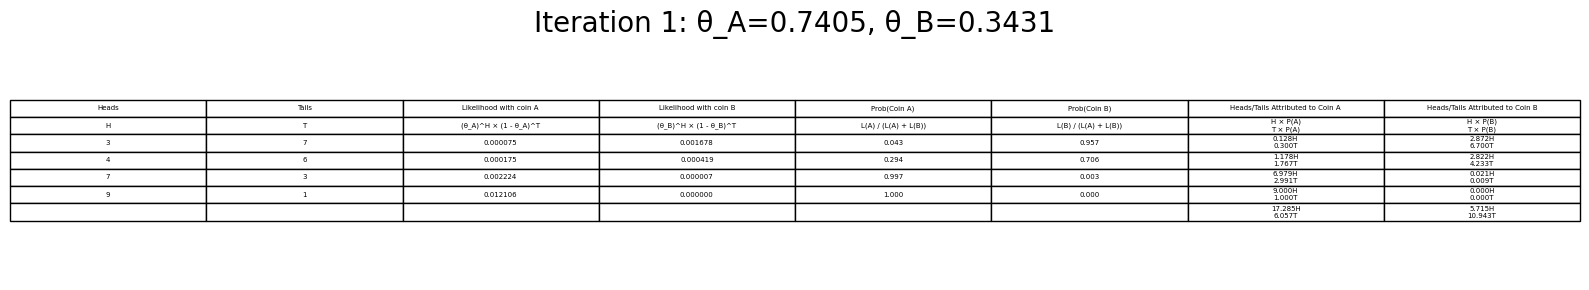

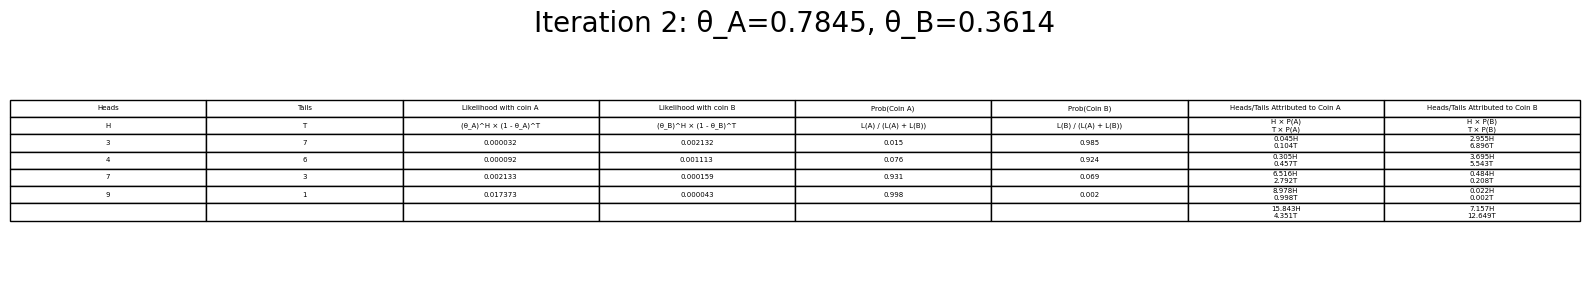

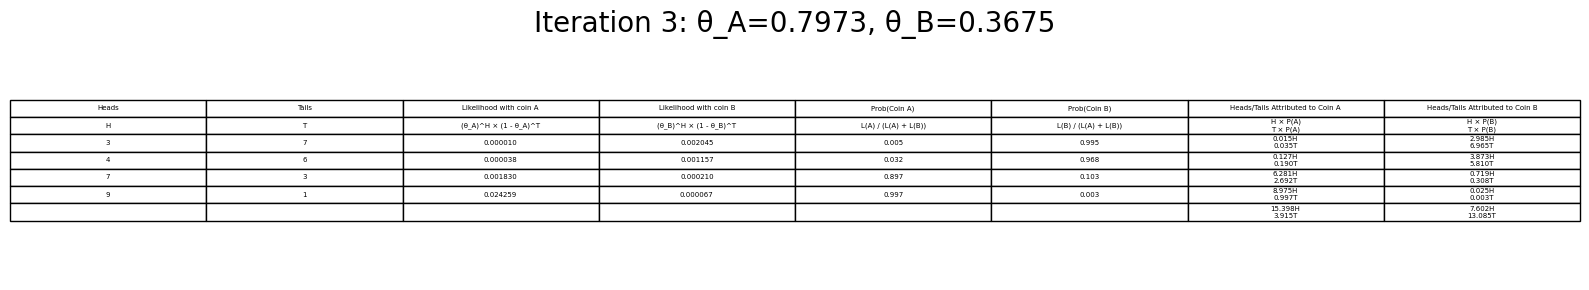

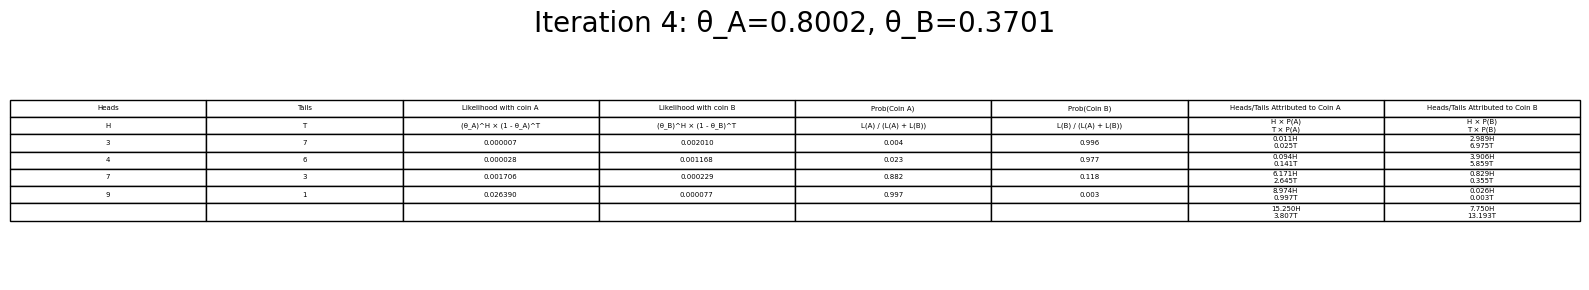

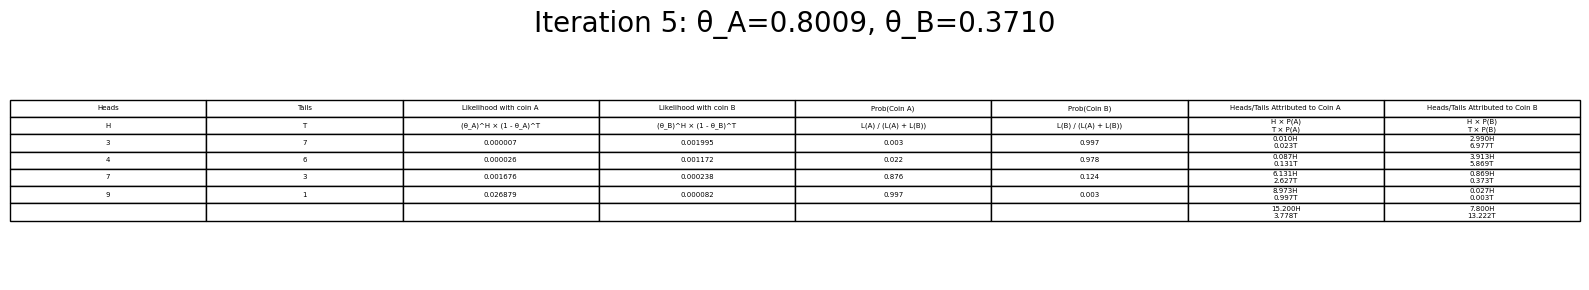

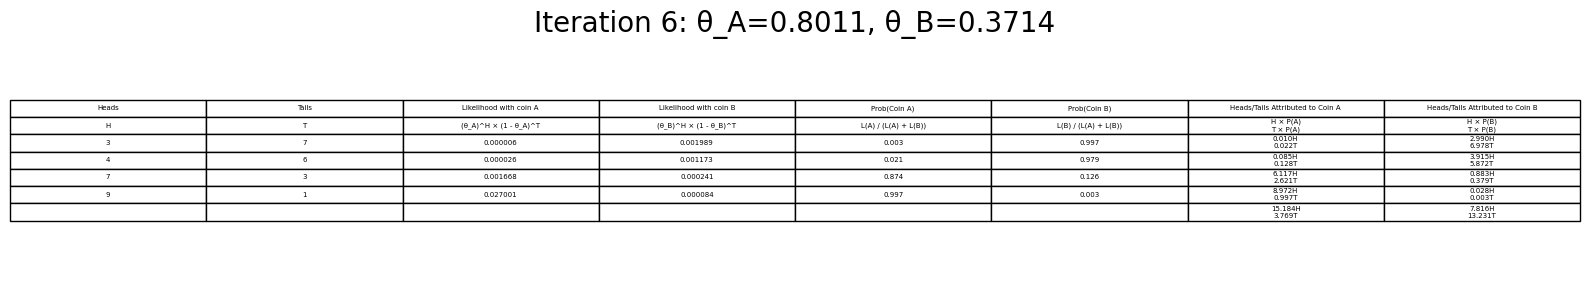

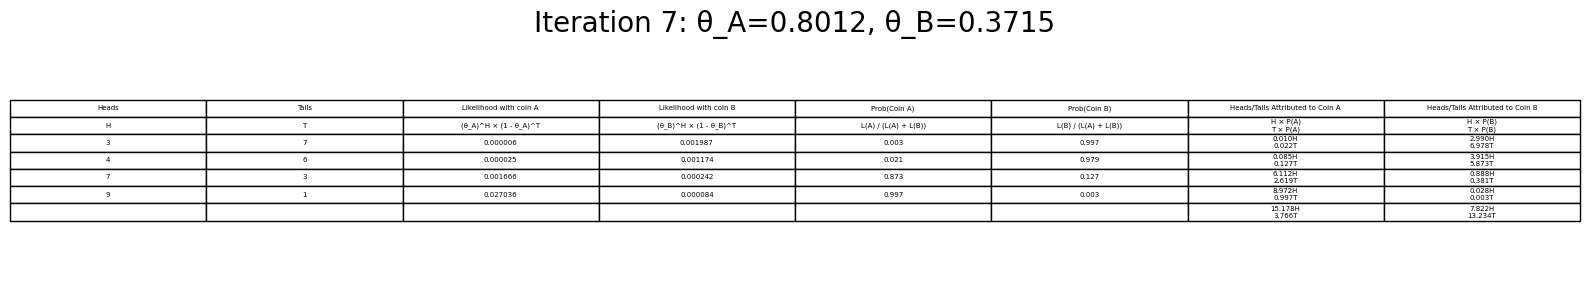

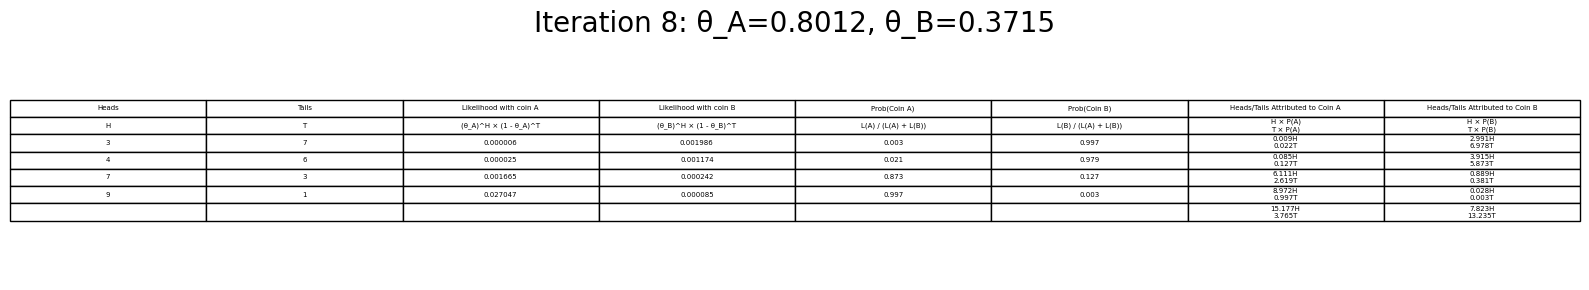

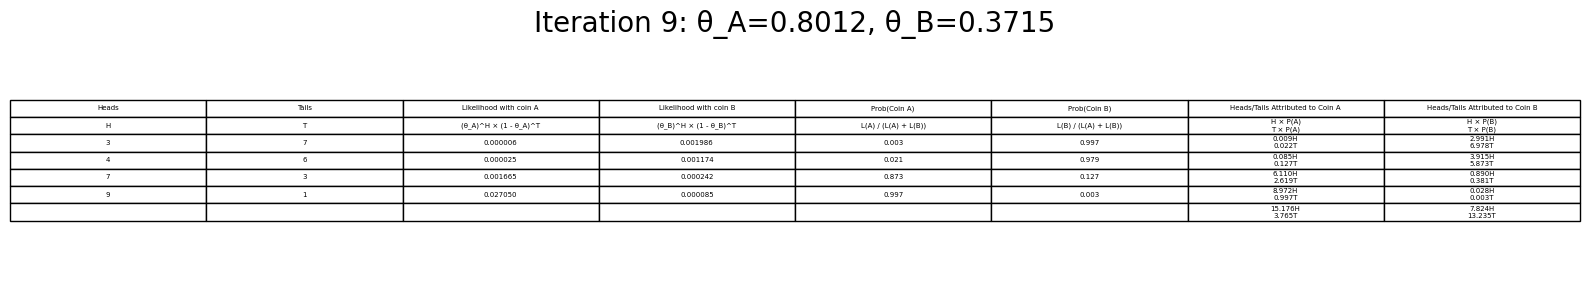

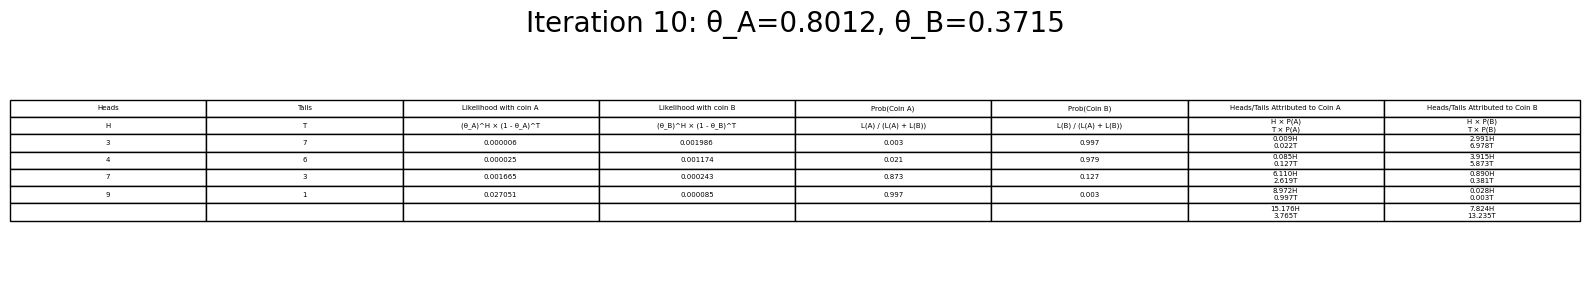

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Initial parameters
theta_A = 0.70000
theta_B = 0.20000

# Observed sequences (H, T)
sequences = [(3, 7), (4, 6), (7, 3), (9, 1)]

def format_ht(h, t):
    return f"{h:.3f}H\n{t:.3f}T"

for iteration in range(1, 11):
    table_data = []

    # Formula row (no LaTeX parsing for line breaks)
    table_data.append([
        "H", "T",
        "(θ_A)^H × (1 - θ_A)^T",
        "(θ_B)^H × (1 - θ_B)^T",
        "L(A) / (L(A) + L(B))",
        "L(B) / (L(A) + L(B))",
        "H × P(A)\nT × P(A)",
        "H × P(B)\nT × P(B)"
    ])

    sum_H_A = sum_T_A = sum_H_B = sum_T_B = 0.0

    for H, T in sequences:
        # Likelihoods
        L_A = (theta_A ** H) * ((1 - theta_A) ** T)
        L_B = (theta_B ** H) * ((1 - theta_B) ** T)
        # Probabilities
        P_A = L_A / (L_A + L_B)
        P_B = 1 - P_A
        # Attributed heads/tails
        H_A = H * P_A
        T_A = T * P_A
        H_B = H * P_B
        T_B = T * P_B

        sum_H_A += H_A
        sum_T_A += T_A
        sum_H_B += H_B
        sum_T_B += T_B

        table_data.append([
            H, T,
            f"{L_A:.6f}", f"{L_B:.6f}",
            f"{P_A:.3f}", f"{P_B:.3f}",
            format_ht(H_A, T_A),
            format_ht(H_B, T_B)
        ])

    # Update parameters
    theta_A = sum_H_A / (sum_H_A + sum_T_A)
    theta_B = sum_H_B / (sum_H_B + sum_T_B)

    # Totals row
    table_data.append([
        "", "",
        "", "",
        "", "",
        format_ht(sum_H_A, sum_T_A),
        format_ht(sum_H_B, sum_T_B)
    ])
    
    # Create DataFrame
    df = pd.DataFrame(table_data, columns=[
        "Heads", "Tails",
        "Likelihood with coin A",
        "Likelihood with coin B",
        "Prob(Coin A)", "Prob(Coin B)",
        "Heads/Tails Attributed to Coin A",
        "Heads/Tails Attributed to Coin B"
    ])

    # Save as image
    fig, ax = plt.subplots(figsize=(16, 3))
    ax.axis('off')
    ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')
    plt.title(f"Iteration {iteration}: θ_A={theta_A:.4f}, θ_B={theta_B:.4f}", fontsize=20)
    plt.tight_layout()
    # plt.savefig(f"tmp/table_{iteration}.png", dpi=300)
    plt.show()
    plt.close()
